In [55]:
import os
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from collections import Counter

## 경로고정

In [40]:
project_root = Path("..")
data_dir = project_root / "data"
artifacts_dir = project_root / "artifacts" / "eda"
artifacts_dir.mkdir(parents = True, exist_ok = True)

print("project_root : ", project_root.resolve())
print("data_dir : ", data_dir.resolve())
print("artifacts_dir : ", artifacts_dir.resolve())

project_root :  /root/Project
data_dir :  /root/Project/data
artifacts_dir :  /root/Project/artifacts/eda


## CSV 로딩 (train / meta) + Check

In [41]:
train_df = pd.read_csv(data_dir / "train.csv")
meta_df = pd.read_csv(data_dir / "meta.csv")

print("train_df shape : ", train_df.shape)
print("meta_df shape : ", meta_df.shape)

display(train_df.head())
display(meta_df.head())

# Class 개수 확인하기
print("클래스 개수 : ", train_df["target"].nunique())

train_df shape :  (1570, 2)
meta_df shape :  (17, 2)


,ID,target
0,002f99746285dfdd.jpg,16
1,008ccd231e1fea5d.jpg,10
2,008f5911bfda7695.jpg,10
3,009235e4c9c07af5.jpg,4
4,00b2f44967580c74.jpg,16


,target,class_name
0,0,account_number
1,1,application_for_payment_of_pregnancy_medical_e...
2,2,car_dashboard
3,3,confirmation_of_admission_and_discharge
4,4,diagnosis


클래스 개수 :  17


## Target -> Class_name 매핑하기

In [42]:
class_map = meta_df.set_index("target")["class_name"].to_dict()

print("맵핑 Sample : ", list(class_map.items())[:5])

train_df["class_name"] = train_df["target"].map(class_map)
display(train_df.head())

맵핑 Sample :  [(0, 'account_number'), (1, 'application_for_payment_of_pregnancy_medical_expenses'), (2, 'car_dashboard'), (3, 'confirmation_of_admission_and_discharge'), (4, 'diagnosis')]


,ID,target,class_name
0,002f99746285dfdd.jpg,16,vehicle_registration_plate
1,008ccd231e1fea5d.jpg,10,payment_confirmation
2,008f5911bfda7695.jpg,10,payment_confirmation
3,009235e4c9c07af5.jpg,4,diagnosis
4,00b2f44967580c74.jpg,16,vehicle_registration_plate


## 클래스 분포 (불균형에 관한) 분석 + 저장

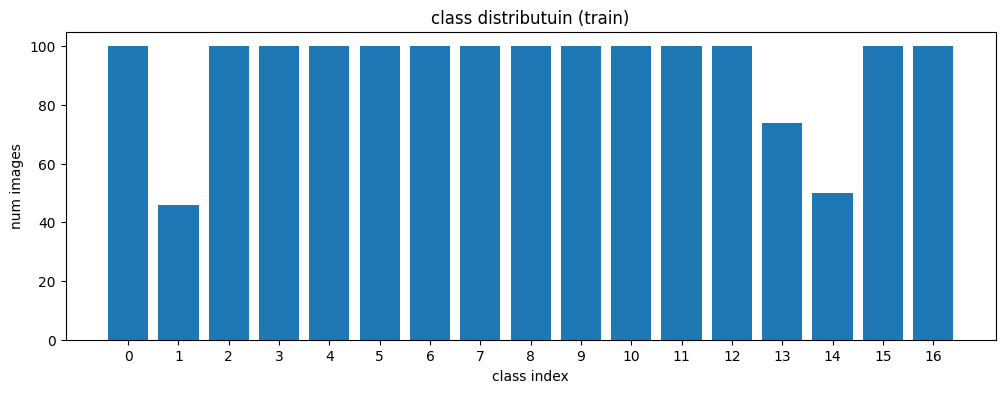

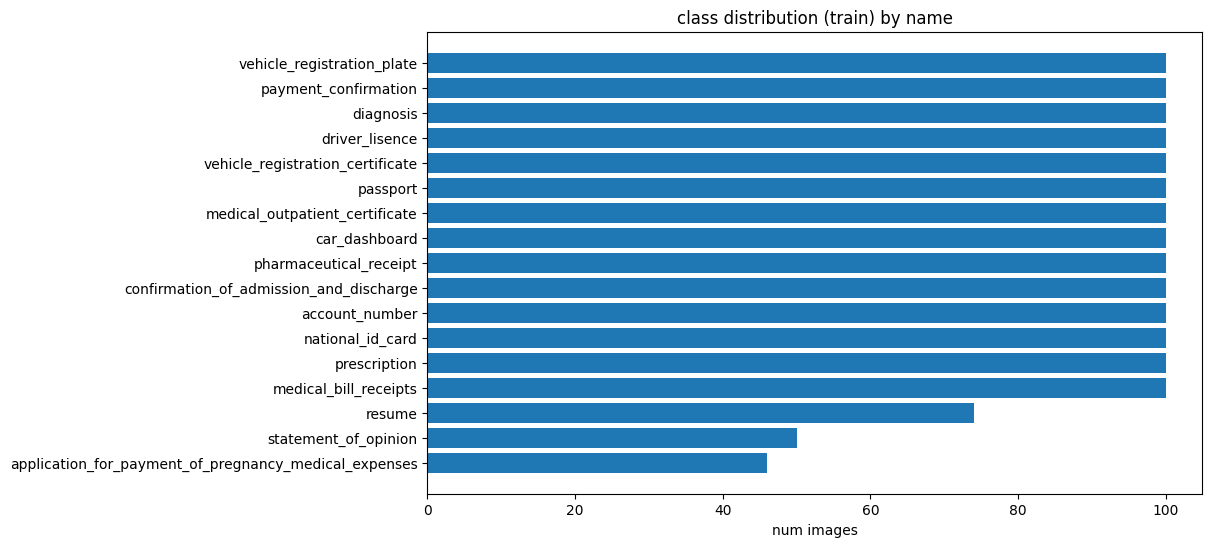

saved :  ../artifacts/eda/class_distribution.json ../artifacts/eda/class_distribution_named.csv


In [43]:
class_counts = train_df["target"].value_counts().sort_index()
# 클래스마다 사진이 몇 장 존재하는지 Check

# 클래스 분포 Title (0~16 값으로 되어 있는걸 그대로 출력)
plt.figure(figsize=(12,4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("class distributuin (train)")
plt.xlabel("class index")
plt.ylabel("num images")
plt.xticks(rotation=0)
plt.show()

# 위에 이름 mapping 한 그래프도 함께 Check (0~16 값을 class_name 으로 매핑한 결과로 보기)
class_counts_named = train_df["class_name"].value_counts()

plt.figure(figsize=(10,6))
plt.barh(class_counts_named.index, class_counts_named.values)
plt.title("class distribution (train) by name")
plt.xlabel("num images")
plt.gca().invert_yaxis()
plt.show()

# artifacts에 저장
class_counts.to_json(artifacts_dir / "class_distribution.json")
class_counts_named.to_csv(artifacts_dir / "class_distribution_named.csv")

print("saved : ", artifacts_dir / "class_distribution.json", artifacts_dir / "class_distribution_named.csv")

## 이미지 파일 존재/누락 Check

In [44]:
train_img_dir = data_dir / "train"
missing = []

for img_id in train_df["ID"].tolist():
    if not (train_img_dir / img_id).exists():
        missing.append(img_id)

print("missing images : ", len(missing))
if missing[:10]:
    print("examples : ", missing[:10])

missing images :  0


## 클래스별 랜덤 샘플 이미지 보기

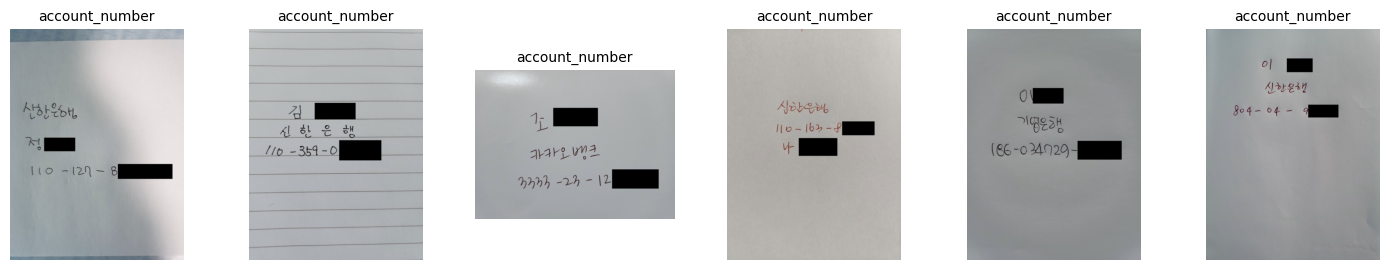

In [45]:
def load_train_image(img_id):
    return Image.open(train_img_dir / img_id).convert("RGB")

def show_samples(target, n=6, seed=42):
    random.seed(seed)
    subset = train_df[train_df["target"] == target]
    ids = subset["ID"].tolist()
    if len(ids) == 0:
        print("no samples for target : ", target)
        return 
    
    pick = random.sample(ids, min(n, len(ids)))
    
    plt.figure(figsize=(3*n, 3))
    for i, img_id in enumerate(pick):
        img = load_train_image(img_id)
        plt.subplot(1, len(pick), i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(class_map[target], fontsize=10)
    plt.show()

# show_samples(0, n=6) 에서 첫번째로 넘겨준 인덱스 값이 class 번호
# 즉 그러니까 1번 Class 에 Sample 을 보고 싶으면 해당 인덱스 1로 수정 (0~16 값으로 수정해서 뽑으면 전체적인 예시를 볼 수 있음)
show_samples(0, n=6)

## 이미지 해상도 분포 (학습 input size 를 결정할 때 쓰일 수 있을거 같음)

widht min/mean/max :  428 487.55 753
height min/mean/max :  348 547.8133333333334 612


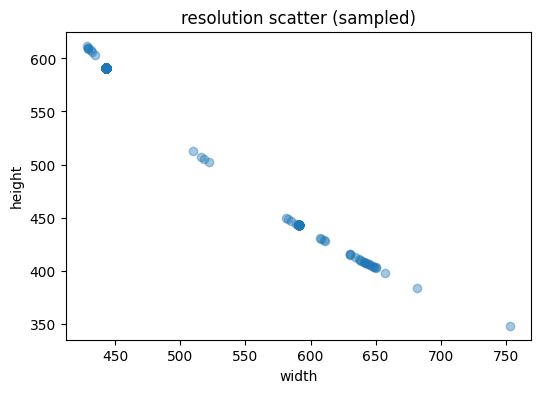

saved :  ../artifacts/eda/resolution_stats.json


In [46]:
# 원본이 대체로 어느정도 크기일까?
# 리사이즈를 어디까지 해도 괜찮을까? 들에 대한 기준점을 보기위한

w_list, h_list = [], []
sample_ids = train_df["ID"].sample(min(300, len(train_df)), random_state = 42).tolist()

for img_id in sample_ids:
    omg = load_train_image(img_id)
    img = load_train_image(img_id)
    w, h = img.size
    w_list.append(w)
    h_list.append(h)

w_arr = np.array(w_list)
h_arr = np.array(h_list)

print("widht min/mean/max : ", w_arr.min(), w_arr.mean(), w_arr.max())
print("height min/mean/max : ", h_arr.min(), h_arr.mean(), h_arr.max())

# 그래프화
plt.figure(figsize=(6,4))
plt.scatter(w_arr, h_arr, alpha=0.4)
plt.xlabel("width")
plt.ylabel("height")
plt.title("resolution scatter (sampled)")
plt.show()

# 저장
stats = {
    "width_min": int(w_arr.min()),
    "width_mean": float(w_arr.mean()),
    "width_max": int(w_arr.max()),
    "height_min": int(h_arr.min()),
    "height_mean": float(h_arr.mean()),
    "height_max": int(h_arr.max()),
    "n_sampled": int(len(sample_ids)),
}
pd.Series(stats).to_json(artifacts_dir / "resolution_stats.json")
print("saved : ", artifacts_dir / "resolution_stats.json")

## Train vs Test 이미지를 직접 비교

In [47]:
# 데이터 불러오기
test_df = pd.read_csv(data_dir / "sample_submission.csv")
test_img_dir = data_dir / "test"

print("test samples : ", len(test_df))
display(test_df.head())

test samples :  3140


,ID,target
0,0008fdb22ddce0ce.jpg,0
1,00091bffdffd83de.jpg,0
2,00396fbc1f6cc21d.jpg,0
3,00471f8038d9c4b6.jpg,0
4,00901f504008d884.jpg,0


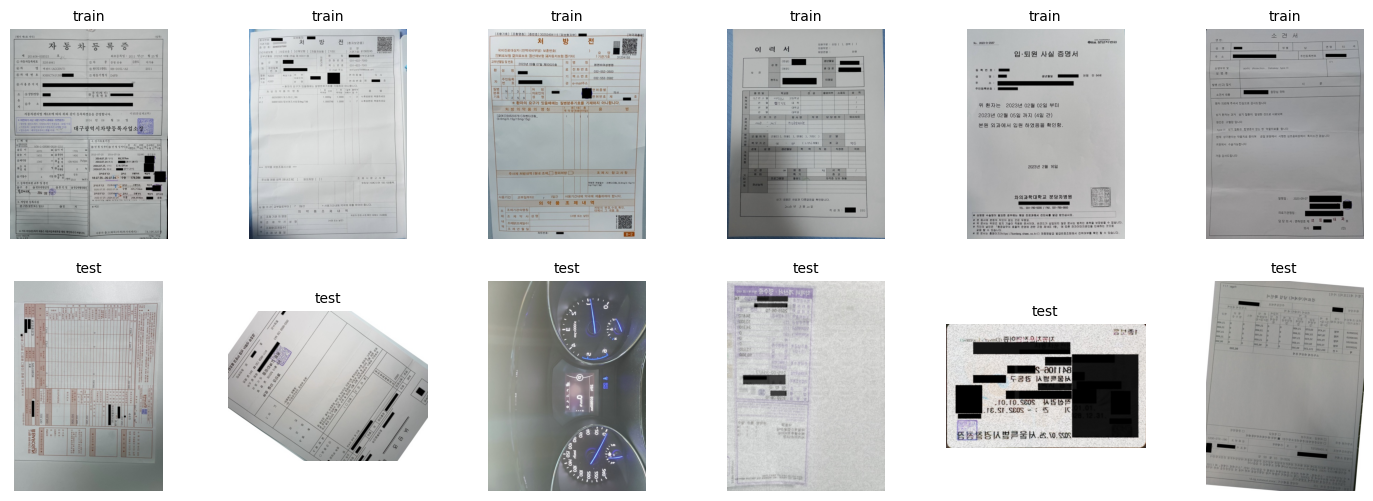

In [48]:
def load_test_image(img_id):
    return Image.open(test_img_dir / img_id).convert("RGB")

def compare_train_test(n=6, seed=42):
    random.seed(seed)

    train_ids = random.sample(train_df["ID"].tolist(), n)
    test_ids = random.sample(test_df["ID"].tolist(), n)

    plt.figure(figsize=(3*n, 6))

    # train
    for i, img_id in enumerate(train_ids):
        img = load_train_image(img_id)
        plt.subplot(2, n, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title("train", fontsize=10)

    # test
    for i, img_id in enumerate(test_ids):
        img = load_test_image(img_id)
        plt.subplot(2, n, n+i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title("test", fontsize=10)
    
    plt.show()

compare_train_test(n=6)

## Test 이미지에서 회전관련된 부분 관찰

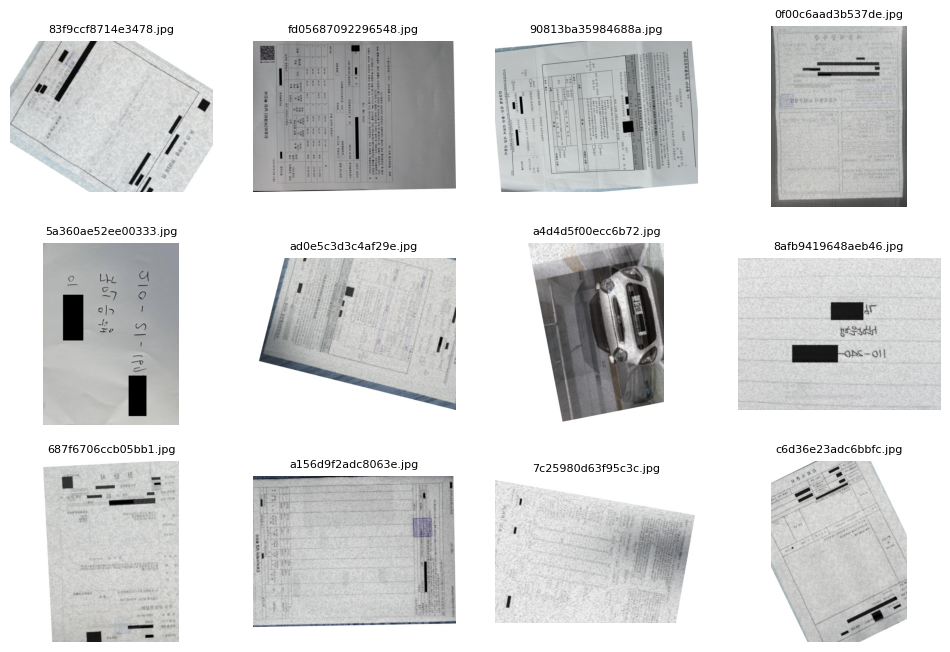

In [49]:
def show_test_samples(n=12, seed=0):
    random.seed(seed)
    ids = random.sample(test_df["ID"].tolist(), n)

    plt.figure(figsize=(12, 8))
    for i, img_id in enumerate(ids):
        img = load_test_image(img_id)
        plt.subplot(3, 4, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_id, fontsize=8)
    plt.show()

show_test_samples()

## 클래스별 오답 위험도 추정

추진 목적
1. 클래스 별 이미지 성격을 분류하는데,
예를 들어 '텍스트 위주 문서인지, 도장/사진이 포함되어 있는지, 레이아웃이 규칙적인지, 촬영 각도에 민감한지' 에 대한 성격을 분류해놓으면
ex) 진단서 / 소견서 / 처방전은 텍스트 + 레이아웃이 유사하고 (사실 사람이 봤을 때에는 생김새는 똑같고 글자로 이게 진단서 인지 소견서 인지 판단할 수 있는 기준이 되기 때문에), 자동차 번호판이나 계기판은 사진 기반이고 문서이기 때문에

2. 초기 Confusion Matrix 가 이렇게 나올 가능성이 높다를 예측할 수 있음

Target 0 : account_number


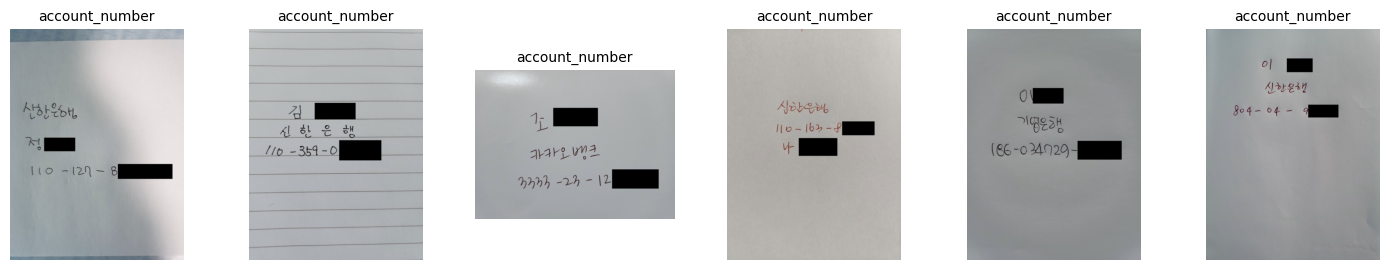

Target 1 : application_for_payment_of_pregnancy_medical_expenses


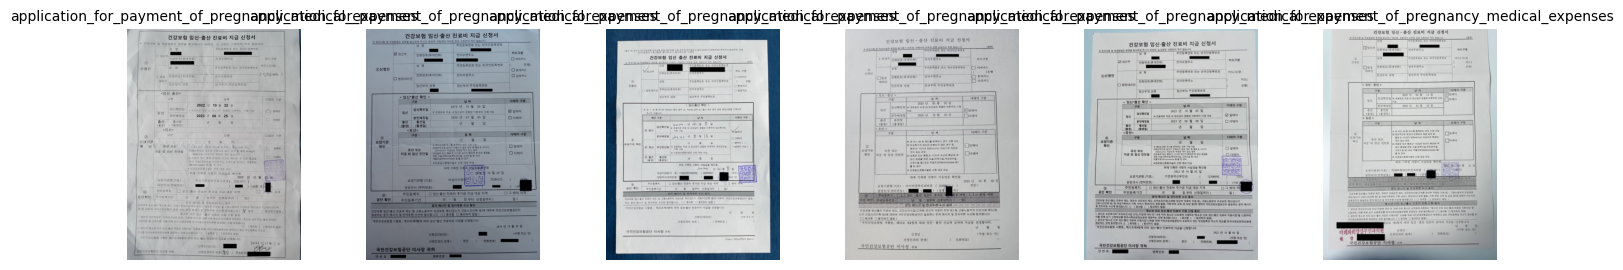

Target 2 : car_dashboard


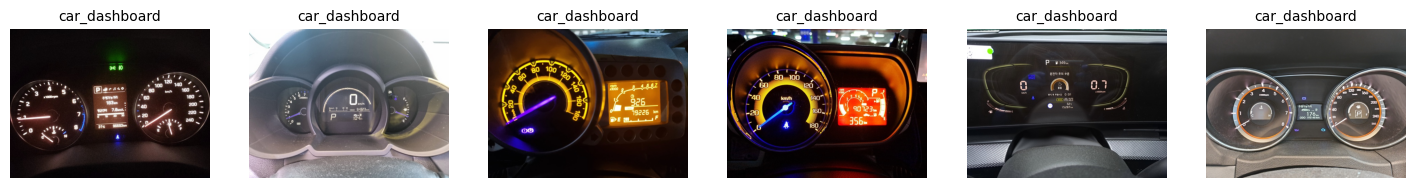

Target 3 : confirmation_of_admission_and_discharge


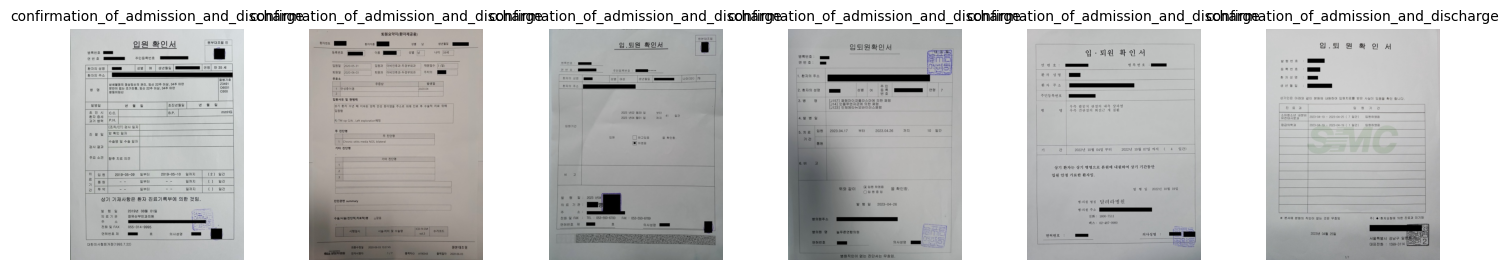

Target 4 : diagnosis


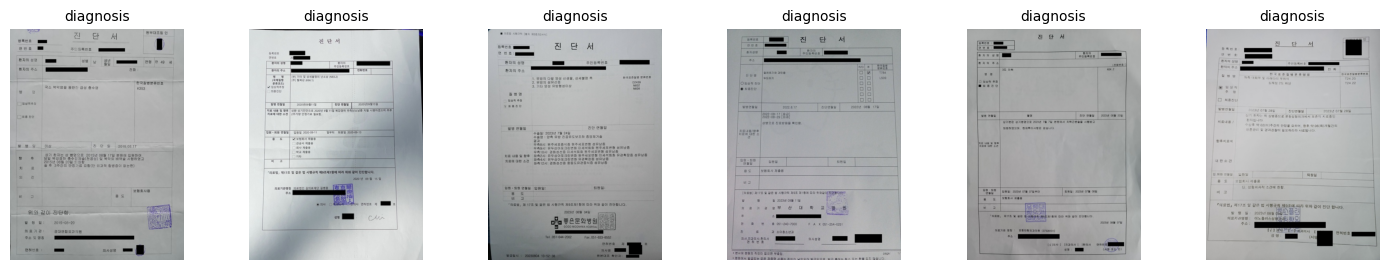

Target 5 : driver_lisence


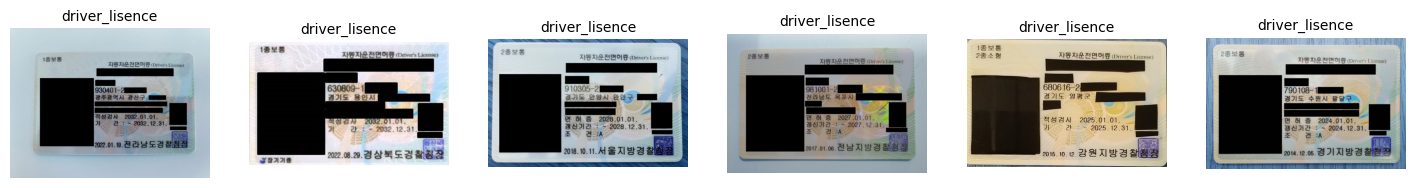

Target 6 : medical_bill_receipts


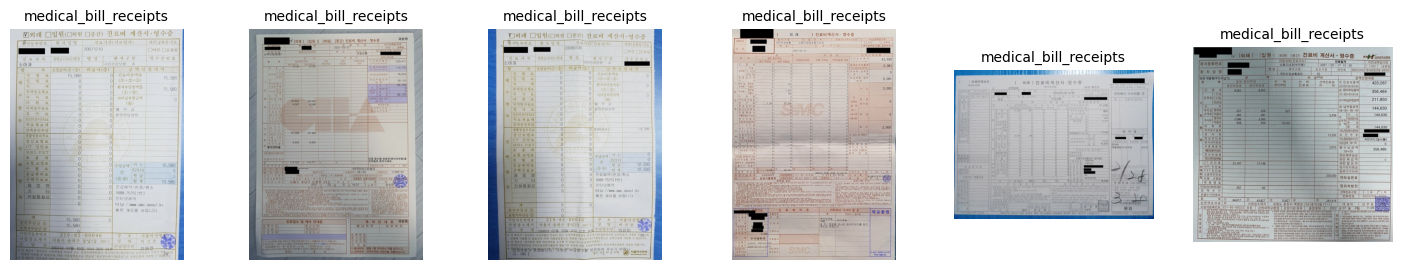

Target 7 : medical_outpatient_certificate


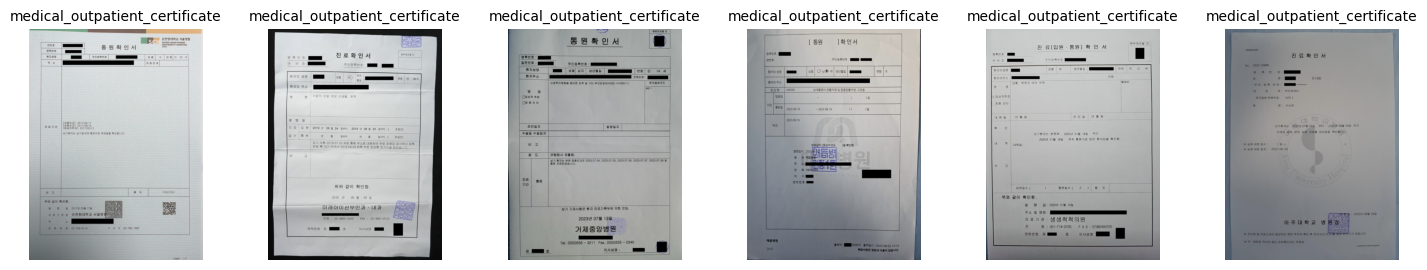

Target 8 : national_id_card


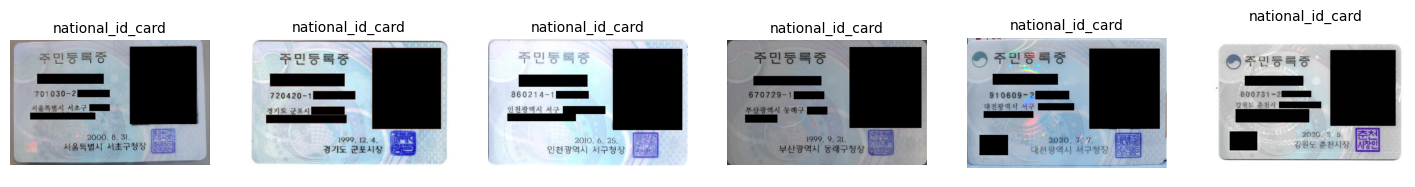

Target 9 : passport


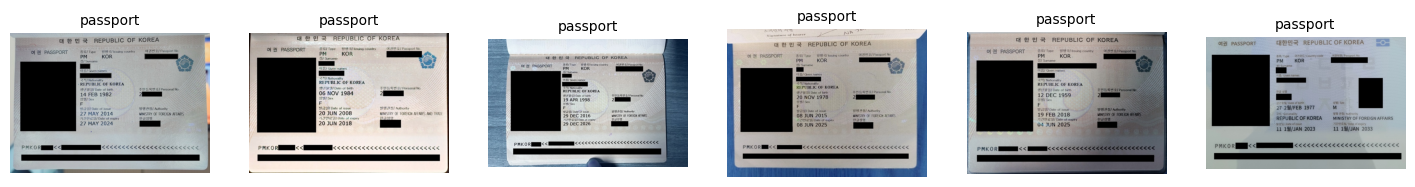

Target 10 : payment_confirmation


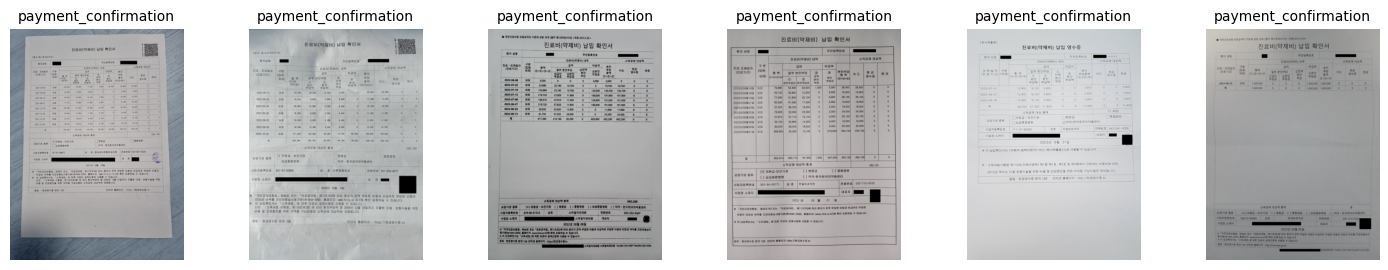

Target 11 : pharmaceutical_receipt


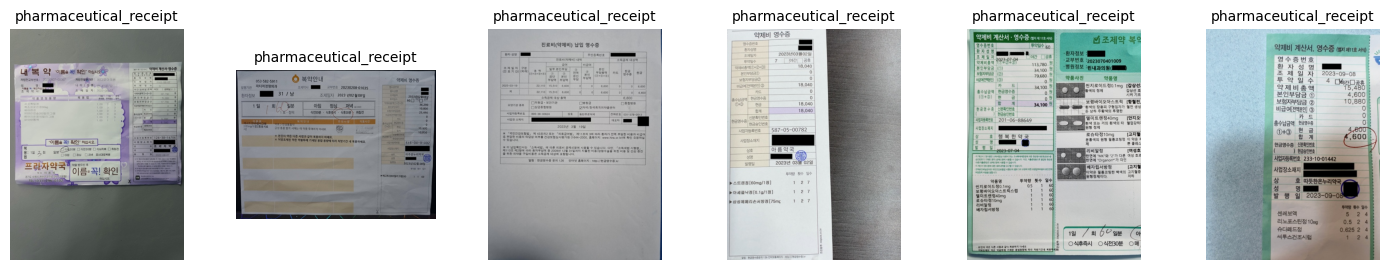

Target 12 : prescription


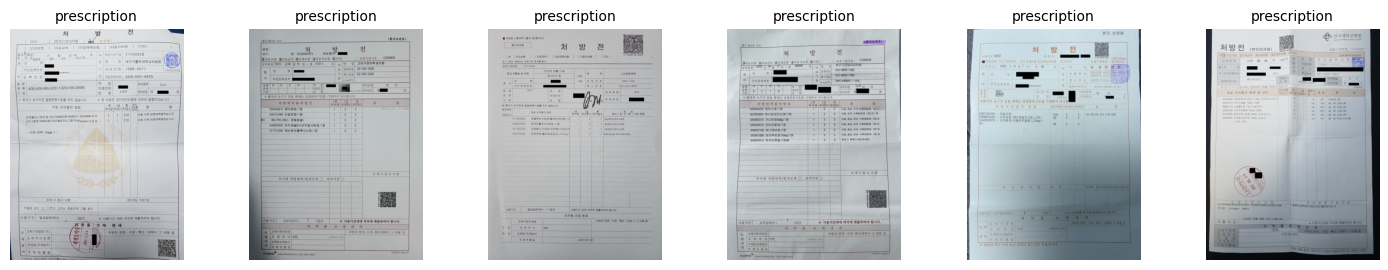

Target 13 : resume


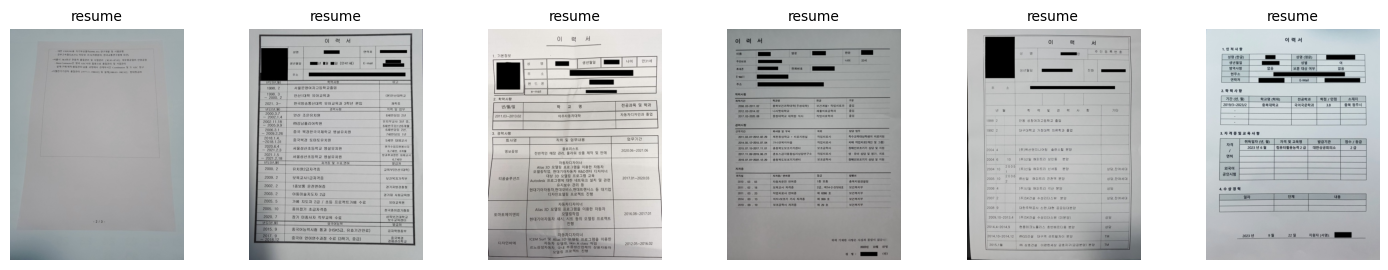

Target 14 : statement_of_opinion


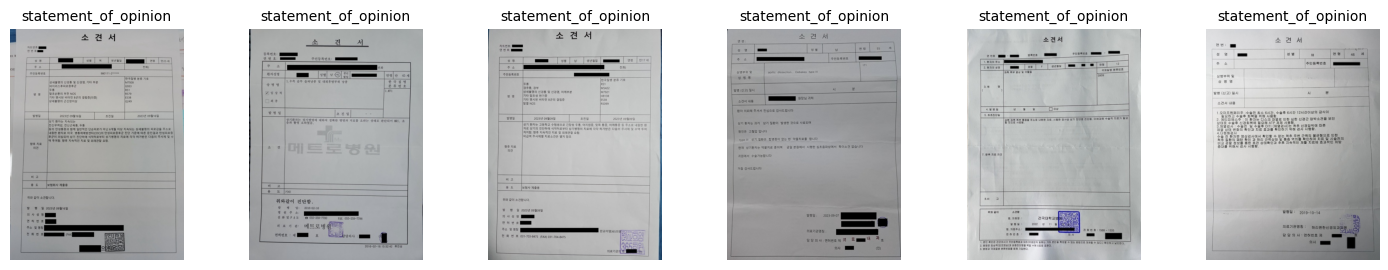

Target 15 : vehicle_registration_certificate


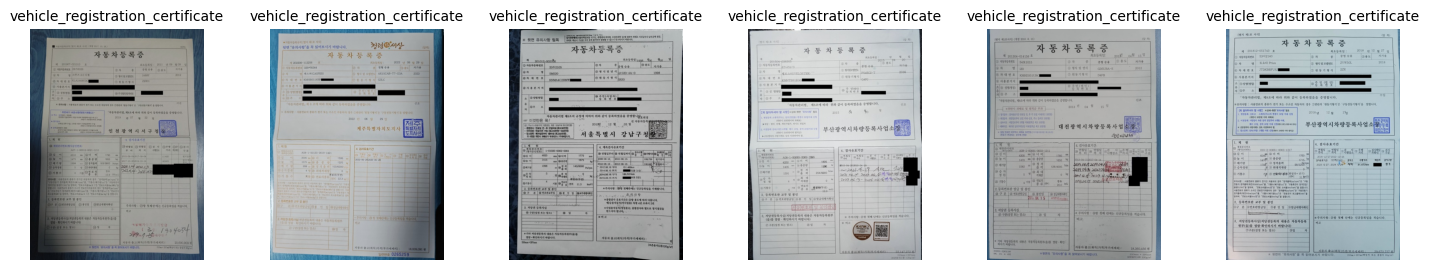

Target 16 : vehicle_registration_plate


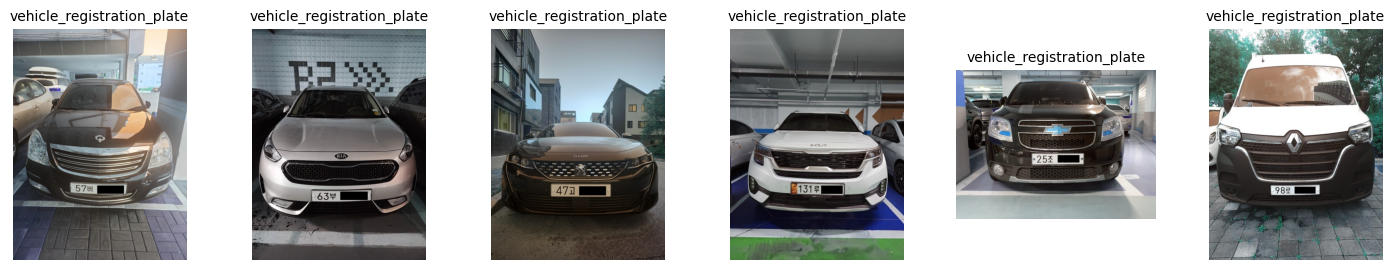

In [50]:
for t in sorted(train_df["target"].unique()):
    print(f"Target {t} : {class_map[t]}")
    show_samples(t, n=6, seed=42)

## Aspect Ratio (가로/세로 비율) 분석 

추진 목적
1. 상위 EDA 에서 width / height 값은 봤는데, Ratio 는 확인 x
이유는 문서는 정사각형이 거의 없고, 강제로 Resize 하면 정보가 왜곡 되서 세로형 문서에 굉장히 치명적일 수 있음

Augmentation 전략 결정에 매우 유리

In [51]:
ratio_arr = w_arr / h_arr

print("ratio min / mean / max : ", 
      ratio_arr.min(),
      ratio_arr.mean(),
      ratio_arr.max())

ratio min / mean / max :  0.6993464052287581 0.9291733498121406 2.163793103448276


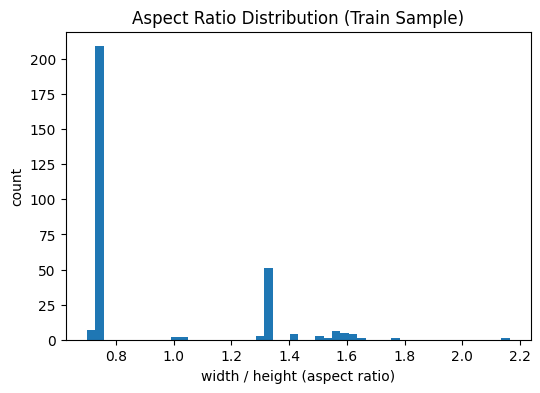

In [52]:
plt.figure(figsize=(6,4))
plt.hist(ratio_arr, bins=50)
plt.xlabel("width / height (aspect ratio)")
plt.ylabel("count")
plt.title("Aspect Ratio Distribution (Train Sample)")
plt.show()

## 문서형 vs 사진형 비율 감각잡기

In [53]:
print("Vertical-like (ratio < 0.75) : ", np.mean(ratio_arr < 0.75))
print("Square-like (0.75 ~ 1.33) : ", np.mean((ratio_arr >= 0.75) & (ratio_arr <= 1.33)))
print("Horizontal-like (ratio > 1.33) : ", np.mean(ratio_arr > 1.33))

Vertical-like (ratio < 0.75) :  0.72
Square-like (0.75 ~ 1.33) :  0.02666666666666667
Horizontal-like (ratio > 1.33) :  0.25333333333333335


In [54]:
# Class 별 Aspect Ratio 성격 파악하기
ratios_by_class = {}

for t in sorted(train_df["target"].unique()):
    ids = train_df[train_df["target"] == t]["ID"].tolist()
    ratios = []
    for img_id in ids[:30]:  # 클래스당 30장만
        img = load_train_image(img_id)
        w, h = img.size
        ratios.append(w / h)
    ratios_by_class[class_map[t]] = np.mean(ratios)

pd.Series(ratios_by_class).sort_values()


application_for_payment_of_pregnancy_medical_expenses    0.749577
confirmation_of_admission_and_discharge                  0.749577
medical_outpatient_certificate                           0.749577
diagnosis                                                0.749577
prescription                                             0.749577
statement_of_opinion                                     0.749577
payment_confirmation                                     0.749577
resume                                                   0.749619
vehicle_registration_certificate                         0.769061
vehicle_registration_plate                               0.944413
medical_bill_receipts                                    0.946763
account_number                                           1.002864
pharmaceutical_receipt                                   1.022348
car_dashboard                                            1.314602
national_id_card                                         1.419145
passport  

## '회전각도' 수치화?

추진 목적
1. "많이 돌아가있다" 는 정성 판단이고 가능하면 각도 범위를 추정하면서 Augmentation 범위를 정하기가 좋음

너무 정확할 필요는 없고 그냥 육안으로 봤을 때 '아 몇도 정도 돌아가 있구나' 를 판단할 수 있을 정도?

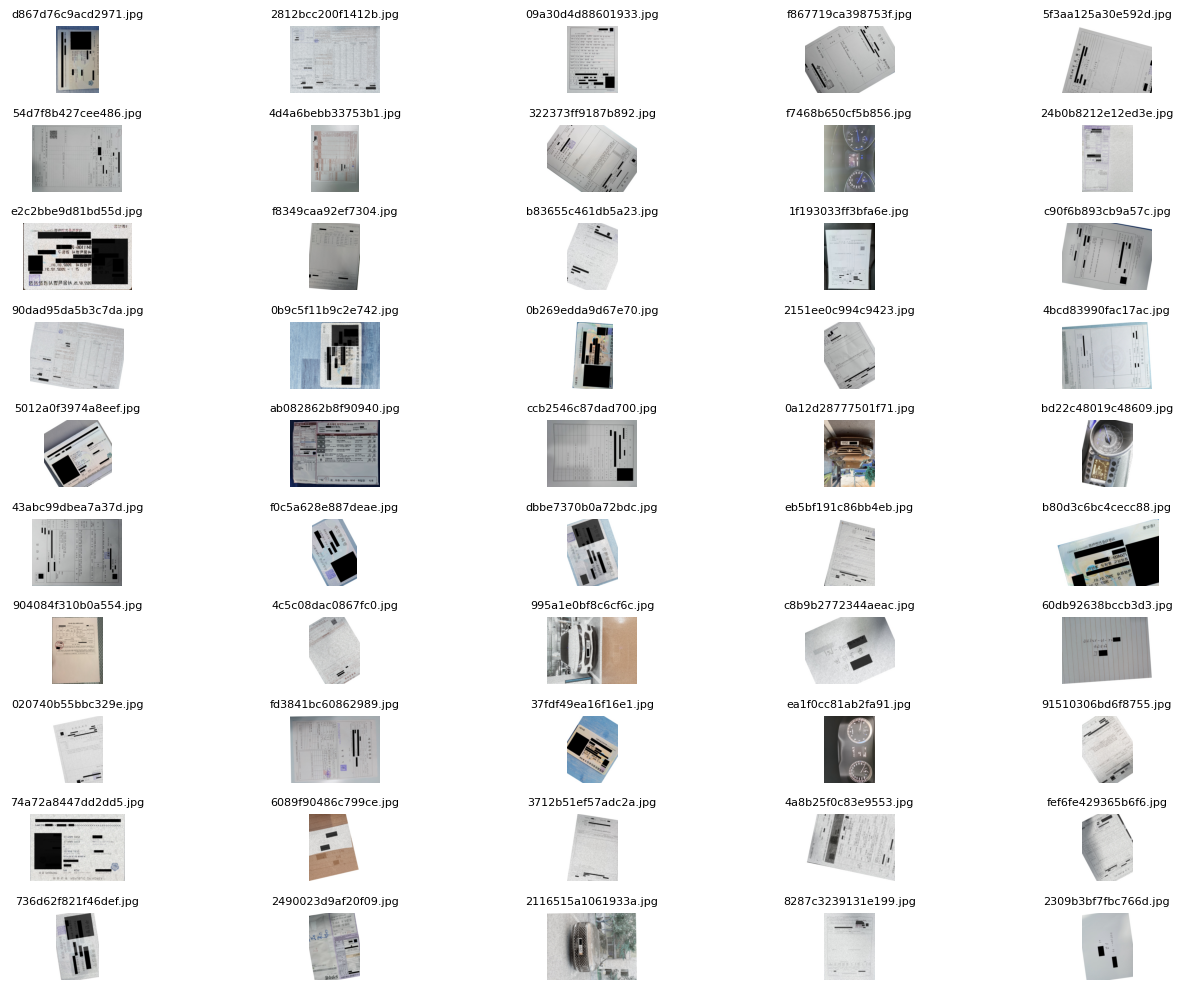

saved: ../artifacts/eda/rotation_bucket_label_template.csv


In [56]:
def show_test_grid(ids, cols=5, figsize=(14,10)):
    rows = int(np.ceil(len(ids)/cols))
    plt.figure(figsize=figsize)
    for i, img_id in enumerate(ids):
        img = load_test_image(img_id)
        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_id, fontsize=8)
    plt.tight_layout()
    plt.show()

# 1. 샘플 뽑기
N = 50  # 한 번에 보기 좋은 수
seed = 42
random.seed(seed)
sample_ids = random.sample(test_df["ID"].tolist(), N)

show_test_grid(sample_ids, cols=5)

# 2. 버킷 라벨을 수기로 기록할 파일 생성(템플릿)
buckets = ["B0(0-5)", "B1(5-15)", "B2(15-30)", "B3(30-60)", "B4(90/180)"]
template = pd.DataFrame({"ID": sample_ids, "rotation_bucket": ""})
template.to_csv(artifacts_dir / "rotation_bucket_label_template.csv", index=False)
print("saved:", artifacts_dir / "rotation_bucket_label_template.csv")

In [57]:
labeled = pd.read_csv(artifacts_dir / "rotation_bucket_label_template.csv")
counts = labeled["rotation_bucket"].value_counts(dropna=False)
print(counts)
counts.to_csv(artifacts_dir / "rotation_bucket_counts.csv")

rotation_bucket
NaN    50
Name: count, dtype: int64


## Blur / Noise 강도 체감

추진 목적
1. GaussianBlur 면 kernel size 는 어느정도?
2. Motion blure 느낌도 있나?
3. JPEG artifact (압축 깨짐) 느낌 있나?